In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df=pd.read_csv('data/stud.csv')
df.head()
df.shape

(1000, 8)

In [36]:
x=df.drop('math_score',axis=1)
x.shape

(1000, 7)

In [37]:
y=df['math_score']

y.shape

(1000,)

In [38]:
num_features = x.select_dtypes(exclude='object').columns
cat_features = x.select_dtypes(include='object').columns


C:\Users\benny\AppData\Local\Temp\ipykernel_25688\1940142949.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = x.select_dtypes(include='object').columns


In [39]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# creating objects
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder()

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])


In [40]:
x=preprocessor.fit_transform(x)

In [41]:
x

array([[ 0.19399858,  0.39149181,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       [ 1.42747598,  1.31326868,  1.        , ...,  1.        ,
         1.        ,  0.        ],
       [ 1.77010859,  1.64247471,  1.        , ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [ 0.12547206, -0.20107904,  1.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.60515772,  0.58901542,  1.        , ...,  1.        ,
         1.        ,  0.        ],
       [ 1.15336989,  1.18158627,  1.        , ...,  0.        ,
         0.        ,  1.        ]], shape=(1000, 19))

In [42]:
x.shape

(1000, 19)

In [43]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [44]:
x_train.shape,x_test.shape

((800, 19), (200, 19))

In [55]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 6.7 MB/s eta 0:00:16
   - -------------------------------------- 2.6/101.7 MB 6.0 MB/s eta 0:00:17
   - -------------------------------------- 3.9/101.7 MB 5.9 MB/s eta 0:00:17
   -- ------------------------------------- 5.2/101.7 MB 5.9 MB/s eta 0:00:17
   -- ------------------------------------- 6.6/101.7 MB 6.0 MB/s eta 0:00:16
   -- ------------------------------------- 7.3/101.7 MB 6.0 MB/s eta 0:00:16
   --- ------------------------------------ 8.7/101.7 MB 5.7 MB/s eta 0:00:17
   --- ------------------------------------ 10.0/101.7 MB 5.7 MB/s eta 0:00:16
   ---- ----------------------------------- 11.8/101.7 MB 6.0 MB/s eta 0:00:15
   ----- ---------------------------------- 13.4/101.7 MB 6.1 MB/s eta 0:00:15
   ----- ---------------------------------- 14.7/101.7 MB 6.1 MB/s eta 0:00


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
#models selction
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
models={
    'LinearRegression':LinearRegression(),
    'Ridge':Ridge(),
    'Lasso':Lasso(),
    'DecisionTreeRegressor':DecisionTreeRegressor(),
    'RandomForestRegressor':RandomForestRegressor(),
    'XGBRegressor':XGBRegressor(),
    'CatBoostRegressor':CatBoostRegressor(verbose=False),
    'AdaBoostRegressor':AdaBoostRegressor(),
    'KNeighborsRegressor':KNeighborsRegressor()
}


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    r2 = r2_score(true, predicted)
    return mae, mse, r2

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    model_train_mae, model_train_mse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_mse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance on training data')
    print('MAE:', model_train_mae)
    print('MSE:', model_train_mse)
    print('R2:', model_train_r2)
    print()

    print('Model performance on testing data')
    print('MAE:', model_test_mae)
    print('MSE:', model_test_mse)
    print('R2:', model_test_r2)
    print()

    r2_list.append(model_test_r2)
    print('=' * 35)
    print('\n')

LinearRegression
Model performance on training data
MAE: 4.266711846071956
MSE: 28.33487038064859
R2: 0.8743172040139593

Model performance on testing data
MAE: 4.214763142474849
MSE: 29.095169866715466
R2: 0.8804332983749565



Ridge
Model performance on training data
MAE: 4.2649878237259795
MSE: 28.337788233082442
R2: 0.8743042615212909

Model performance on testing data
MAE: 4.211100688014259
MSE: 29.05627219234827
R2: 0.880593148502874



Lasso
Model performance on training data
MAE: 5.206296077972952
MSE: 43.478297882726196
R2: 0.8071466723085148

Model performance on testing data
MAE: 5.157879138921815
MSE: 42.506332351273414
R2: 0.8253200795629732



DecisionTreeRegressor
Model performance on training data
MAE: 0.01875
MSE: 0.078125
R2: 0.9996534669718089

Model performance on testing data
MAE: 6.565
MSE: 67.925
R2: 0.7208619765725426



RandomForestRegressor
Model performance on training data
MAE: 1.8320052083333334
MSE: 5.335828694036988
R2: 0.9763322767967516

Model performan

In [60]:
pd.DataFrame({'Model': model_list, 'R2 Score': r2_list}).sort_values(by='R2 Score', ascending=False)

,Model,R2 Score
1,Ridge,0.880593
0,LinearRegression,0.880433
7,AdaBoostRegressor,0.854546
4,RandomForestRegressor,0.853971
6,CatBoostRegressor,0.851632
2,Lasso,0.825320
5,XGBRegressor,0.821221
8,KNeighborsRegressor,0.783770
3,DecisionTreeRegressor,0.720862


In [62]:
#using linear regression

lin_model=LinearRegression()
lin_model=lin_model.fit(x_train,y_train)
y_pred=lin_model.predict(x_test)
score=r2_score(y_test, y_pred)*100
print("Accuracy of Linear Regression model is: ", score)


Accuracy of Linear Regression model is:  88.04332983749565


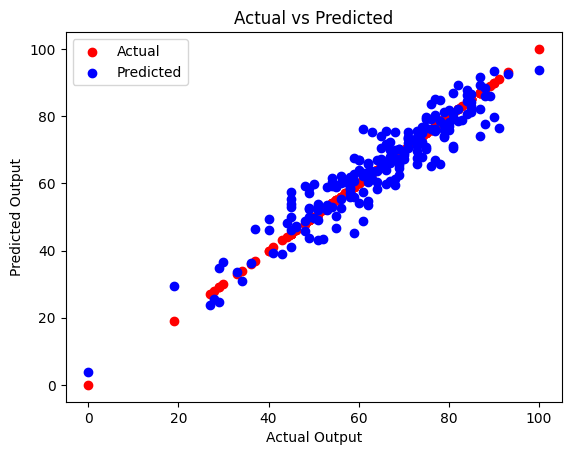

In [66]:
plt.scatter(y_test, y_test, color='red', label='Actual')

# Predicted values
plt.scatter(y_test, y_pred, color='blue', label='Predicted')



plt.xlabel('Actual Output')
plt.ylabel('Predicted Output')
plt.title('Actual vs Predicted')

plt.legend()
plt.show()

In [69]:
pred_df=pd.DataFrame({'Actual': y_test, 'Predicted': y_pred,'Difference': y_test - y_pred})
pred_df.head()

,Actual,Predicted,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
